In [1]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [20]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement scikit-learn (from versions: none)
ERROR: No matching distribution found for scikit-learn


In [2]:
import torch
print(torch.__version__)

d:\olo\PSU\Компьютерное зрение\2026\4\.venv\Lib\site-packages\torch\_subclasses\functional_tensor.py:283: UserWarning: Failed to initialize NumPy: No module named 'numpy' (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:84.)
  cpu = _conversion_method_template(device=torch.device("cpu"))


2.10.0+cpu


## Перцептрон в PyTorch

$x = (x_1, ..., x_n)$ — вектор с данными.

$y = (y_1, ..., y_k)$ — то, что хотим предсказать, используя $x$.

Сначала попробуем на совсем простой модели:

$\hat{y} = \sigma ( x^T \cdot W + b)$

$$
W =
\begin{pmatrix}
w_{1,1} & w_{1,2} & ... & w_{1,k}\\
...&...&...&...\\
w_{n,1} & w_{n,2} & ... & w_{n,k}\\
\end{pmatrix}
- \text{Матрица весов}\quad ; \quad b =
\begin{pmatrix}
b_{1} & b_{2} & ... & b_{k}\\
\end{pmatrix}
- \text{Вектор смещения}
$$

$$
x^T \cdot W + b =
\begin{pmatrix}
b_1 + \sum_{i=1}^{n} x_i \cdot w_{i,1} & b_2 + \sum_{i=1}^{n} x_i \cdot w_{i,2} & ... & b_k + \sum_{i=1}^{n} x_i \cdot w_{i,k}\\
\end{pmatrix}
$$

$\sigma(a) = \frac{1}{1 + e^{-a}}$ — функция «сигмоида», в нашем случае применяется поэлементно (к каждому элементу вектора по отдельности).

In [3]:
# Пусть есть вектор x и истинный ответ y_true.
x = torch.rand(3)
y_true = torch.tensor([1.])
print(f"x:\n{x}\n\ny_true:\n{y_true}")

x:
tensor([0.6783, 0.4161, 0.3550])

y_true:
tensor([1.])


In [4]:
# Зададим матрицу весов и вектор смещения.
# С помощью параметра requires_grad мы указываем,
#  что для данных тензоров нужно будет считать градиенты.
w = torch.randn(3, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
print(f"w:\n{w}\n\nb:\n{b}")

w:
tensor([[0.0474],
        [0.2314],
        [1.4189]], requires_grad=True)

b:
tensor([0.], requires_grad=True)


In [5]:
# Для вычисления сигмоиды возьмём уже готовую функцию из библиотеки PyTorch.
torch.sigmoid(torch.tensor([1, 0, -1]))

tensor([0.7311, 0.5000, 0.2689])

In [6]:
# Вычисляем наше предсказание на основе простой модели.
y_pred = torch.sigmoid(x.T @ w + b)
y_pred

C:\Users\peres\AppData\Local\Temp\ipykernel_21308\156728125.py:2: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4483.)
  y_pred = torch.sigmoid(x.T @ w + b)


tensor([0.6530], grad_fn=<SigmoidBackward0>)

In [7]:
# Знак транспонирования при умножении вектора на матрицу можно не писать.
y_pred = torch.sigmoid(x @ w + b)
y_pred

tensor([0.6530], grad_fn=<SigmoidBackward0>)

In [8]:
# Будем оценивать модуль разницы между оригинальным значением y_true и предсказанным y_pred
#  (в более общем случае сумму по всем k, но в нашем примере k = 1).
loss = ((y_true - y_pred)**2).sum()
loss

tensor(0.1204, grad_fn=<SumBackward0>)

In [9]:
# По сути в переменной loss находится число — величина ошибки.
# Именно это число мы хотим *оптимизировать* при обучении:
#  чем оно меньше после очередной итерации, тем лучше наше предсказание
# Будем называть эту переменную «Величина ошибки обучения» или просто «Ошибка».

# Всё, что нужно для завершения шага обучения нашей простой модели — обновить матрицу весов
#  и вектор смещения, используя соответствующие градиенты (алгоритм градиентного спуска).

# Получить градиенты для любой переменной можно с помощью параметра .grad,
#  однако изначально они ничем не инициализированы.
print(
    f"До применения backward",
    f"w.grad:\n{w.grad}",
    f"b.grad:\n{b.grad}",
    sep="\n\n",
    end="\n\n---------\n\n",
)

# Функция backward(), используя граф вычислений, дойдёт по нему до всех переменных
#  с requires_grad = True и посчитает для них градиенты.
# Воспользуемся ей для расчёта градиентов относительно ошибки предсказания.
loss.backward()

print(
    f"После применения backward",
    f"w.grad:\n{w.grad}",
    f"b.grad:\n{b.grad}",
    sep="\n\n",
)

До применения backward

w.grad:
None

b.grad:
None

---------

После применения backward

w.grad:
tensor([[-0.1067],
        [-0.0654],
        [-0.0558]])

b.grad:
tensor([-0.1573])


In [10]:
# Обновим наши веса в соответствии с полученными градиентами.
# Пока не используем параметр «шаг градиентного спуска».
print(
    f"До обновления",
    f"w:\n{w}",
    f"b:\n{b}",
    sep="\n\n",
    end="\n\n---------\n\n",
)

with torch.no_grad():
    # Специальная обёртка, чтобы указать, что операции внутри
    #  не требуют построения графа вычислений или же подсчёта градиентов.

    # Важно, что пишем w -= w.grad, а не w = w - w.grad.
    # Иначе мы не меняем текущую переменную, а создаём новую,
    #  из-за чего слетят настройки requires_grad = True.
    w -= w.grad
    b -= b.grad

print(
    f"После обновления",
    f"w:\n{w}",
    f"b:\n{b}",
    sep="\n\n",
)

До обновления

w:
tensor([[0.0474],
        [0.2314],
        [1.4189]], requires_grad=True)

b:
tensor([0.], requires_grad=True)

---------

После обновления

w:
tensor([[0.1541],
        [0.2968],
        [1.4747]], requires_grad=True)

b:
tensor([0.1573], requires_grad=True)


In [11]:
# ОЧЕНЬ ВАЖНО - градиенты не обнуляются, это нужно делать ВРУЧНУЮ.

print(
    f"До обнуления",
    f"w.grad:\n{w.grad}",
    f"b.grad:\n{b.grad}",
    sep="\n\n",
    end="\n\n---------\n\n",
)

w.grad.zero_()  # In-place обнуление тензора.
b.grad.zero_()

print(
    f"После обнуления",
    f"w.grad:\n{w.grad}",
    f"b.grad:\n{b.grad}",
    sep="\n\n",
)

До обнуления

w.grad:
tensor([[-0.1067],
        [-0.0654],
        [-0.0558]])

b.grad:
tensor([-0.1573])

---------

После обнуления

w.grad:
tensor([[0.],
        [0.],
        [0.]])

b.grad:
tensor([0.])


## Функции активации и функции потерь

In [12]:
# Функции активации.
vec = torch.tensor([1., -0.5, 3., -2.])

print(
    f"Оригинальный тензор:\n{vec}",
    f"sigmoid:\n{torch.sigmoid(vec)}",
    f"tanh:\n{torch.tanh(vec)}",
    f"relu:\n{torch.relu(vec)}",
    f"softmax:\n{torch.softmax(vec, 0)}",
    f"log_softmax:\n{torch.log_softmax(vec, 0)}",
    sep="\n\n",
)

Оригинальный тензор:
tensor([ 1.0000, -0.5000,  3.0000, -2.0000])

sigmoid:
tensor([0.7311, 0.3775, 0.9526, 0.1192])

tanh:
tensor([ 0.7616, -0.4621,  0.9951, -0.9640])

relu:
tensor([1., 0., 3., 0.])

softmax:
tensor([0.1154, 0.0258, 0.8530, 0.0057])

log_softmax:
tensor([-2.1589, -3.6589, -0.1589, -5.1589])


In [13]:
# Функции потерь.
y_true_reg = torch.tensor([1., -1., 2.])
y_pred_reg = torch.tensor([0.8, -0.2, 2.5])

y_true_clf_class = torch.tensor([0, 2, 1])
y_true_clf_probs = torch.tensor([
    [1., 0., 0.],
    [0., 0., 1.],
    [0., 1., 0.],
])
y_pred_clf_log_probs = torch.tensor([
    [0.8, 0.1, 0.1],
    [0.4, 0.1, 0.5],
    [0., 0.98, 0.02],
]).log()
y_pred_clf_scores = torch.tensor([
    [10., 1., -2.5],
    [8., 2., 10.],
    [0., 28., 1.],
])

mse_loss_func = torch.nn.MSELoss()
ce_loss_func = torch.nn.CrossEntropyLoss()
nll_loss_func = torch.nn.NLLLoss()

print(
    f"MSE:\n{mse_loss_func(y_pred_reg, y_true_reg)}",
    f"CE с классами в качестве целевых значений:\n{ce_loss_func(y_pred_clf_scores, y_true_clf_class)}",
    f"CE с вероятностями классов в качестве целевых значений:\n{ce_loss_func(y_pred_clf_scores, y_true_clf_probs)}",
    f"NLL с классами в качестве целевых значений (принимать вероятности в качестве целевых значений NLL не умеет):\n{nll_loss_func(y_pred_clf_log_probs, y_true_clf_class)}",
    sep="\n\n",
)

MSE:
0.3100000321865082

CE с классами в качестве целевых значений:
0.042450178414583206

CE с вероятностями классов в качестве целевых значений:
0.042450178414583206

NLL с классами в качестве целевых значений (принимать вероятности в качестве целевых значений NLL не умеет):
0.31216445565223694


## Обучение нейросети

In [14]:
# Обычно нейросеть состоит из множества слоёв.

# Чтобы каждый раз не было необходимости писать вручную преобразования внутри нейронной сети,
#  слои оборачиваются в специального вида классы, позволяющие упростить и ускорить работу с нейросетью.

# Ниже приведён пример того, как можно создать соответствующий класс для линейного слоя нейросети.

# torch.nn.Module - специальный класс в PyTorch. Лучше наследовать собственные классы слоёв
#  от него, чтобы избежать лишней работы по их реализации.
class MyLinear(torch.nn.Module):
    # При наследовании нужно переопределить 2 функции внутри класса:
    #  1. __init__. Эта функция отвечает за инициализацию слоя. В неё передаются параметры,
    #      необходимые для того, чтобы понять, сколько и каких весов будет у слоя,
    #      как их проинициализировать и т.д.
    def __init__(
        self,
        in_features,   # Число параметров на входе в слой.
        out_features,  # Число параметров на выходе из слоя.
    ):
        # Специальная функция для отнаследованных классов. Вызывается в начале __init__.
        super().__init__()
        # Параметры слоя задаём через nn.Parameter, чтобы PyTorch знал, что это обучаемые веса.
        self.weight = torch.nn.Parameter(torch.randn(in_features, out_features))  # Матрица весов.
        self.bias = torch.nn.Parameter(torch.zeros(out_features))                 # Вектор смещения.

    #  2. forward. Эта функция отвечает за прямой проход через слой нейросети
    #      (получает на вход данные, выдаёт преобразованные данные).
    def forward(self, input):
        return (input @ self.weight) + self.bias

In [15]:
# Многие слои уже присутствуют в PyTorch, и их классы находятся в torch.nn.
# К примеру — линейный слой.
linear_layer = torch.nn.Linear(2, 3)

x = torch.rand(2)

linear_layer(x)

tensor([0.0974, 0.0376, 0.2984], grad_fn=<ViewBackward0>)

In [16]:
# Перепишем шаг обучения с нововведениями.
n = 5  # Сколько переменных получаем на вход.
k = 2  # Сколько переменных предсказываем.

batch_size = 10  # Размер батча — по скольким примерам за раз считаем градиент.

# Данные и целевое значение для задачи классификации на k классов.
x = torch.rand(batch_size, n)         # Матрица размера (batch_size x n).
y_true = torch.randint(4, size=(k,))  # Вектор размера (k).

# Будем использовать двухслойную нейросеть:
#  x > Линейный слой 1 > Функция активации 1 > Линейный слой 2 > Softmax (т. к. задача классификации).
hidden_size = 5  # Размер скрытого слоя.
lin1 = torch.nn.Linear(n, hidden_size)
act1 = torch.nn.Tanh()
lin2 = torch.nn.Linear(hidden_size, k)
log_softmax = torch.nn.LogSoftmax(dim=1)  # dim указывает, вдоль какого измерения мы применяем Softmax.

# Полностью наше преобразование будет иметь следующий вид:
y_pred = log_softmax(lin2(act1(lin1(x))))

# Можно записать его поэтапно (например, внутри forward-функции слоя):
h = act1(lin1(x))              # Матрица размера (batch_size x hidden_size).
y_pred = log_softmax(lin2(h))  # Матрица размера (batch_size x k).

# Но так не удобно писать каждый раз, когда мы хотим применить модель.
# Поэтому есть специальная обёртка torch.nn.Sequential(), позволяющая превратить
#  серию слоёв в один слой, применяющий все слои один за другим.
model = torch.nn.Sequential(
    lin1,
    act1,
    lin2,
    log_softmax,
)
print(x)
model(x)

tensor([[0.3497, 0.3488, 0.1062, 0.2278, 0.1347],
        [0.6429, 0.1562, 0.2684, 0.6390, 0.9240],
        [0.8247, 0.6944, 0.5302, 0.3049, 0.1188],
        [0.8273, 0.9976, 0.9028, 0.4667, 0.8038],
        [0.1250, 0.4540, 0.1087, 0.6255, 0.3241],
        [0.2380, 0.5567, 0.0244, 0.5957, 0.7517],
        [0.6734, 0.7992, 0.9031, 0.1559, 0.3258],
        [0.4052, 0.3867, 0.8956, 0.0115, 0.3159],
        [0.0113, 0.8035, 0.9768, 0.7469, 0.8915],
        [0.2433, 0.2166, 0.8784, 0.1416, 0.5711]])


tensor([[-0.7519, -0.6376],
        [-0.7414, -0.6471],
        [-0.7343, -0.6536],
        [-0.6672, -0.7198],
        [-0.6892, -0.6971],
        [-0.6736, -0.7130],
        [-0.7037, -0.6827],
        [-0.7377, -0.6505],
        [-0.6007, -0.7950],
        [-0.7259, -0.6615]], grad_fn=<LogSoftmaxBackward0>)

In [17]:
model

Sequential(
  (0): Linear(in_features=5, out_features=5, bias=True)
  (1): Tanh()
  (2): Linear(in_features=5, out_features=2, bias=True)
  (3): LogSoftmax(dim=1)
)

In [18]:
# Можно задавать Sequential так,
#  чтобы подписи в описании модели были более понятными.
from collections import OrderedDict

model = torch.nn.Sequential(
    OrderedDict([
        ("linear_1", torch.nn.Linear(n, hidden_size)),
        ("activation_1", torch.nn.Tanh()),
        ("linear_2", torch.nn.Linear(hidden_size, k)),
        ("log_softmax", torch.nn.LogSoftmax(dim=1)),
    ])
)

model

Sequential(
  (linear_1): Linear(in_features=5, out_features=5, bias=True)
  (activation_1): Tanh()
  (linear_2): Linear(in_features=5, out_features=2, bias=True)
  (log_softmax): LogSoftmax(dim=1)
)

In [22]:
# Попробуем на конкретных данных.
from sklearn.datasets import make_classification

# Создадим датасет для классификации.
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_classes=2,

    n_informative=2,
    n_redundant=0,
    n_repeated=0,
)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X.shape, y.shape  # 1000 примеров, 2 признака, проводим класификацию на 2 класса.

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# 2 класса.
y.min(), y.max()

(tensor(0), tensor(1))

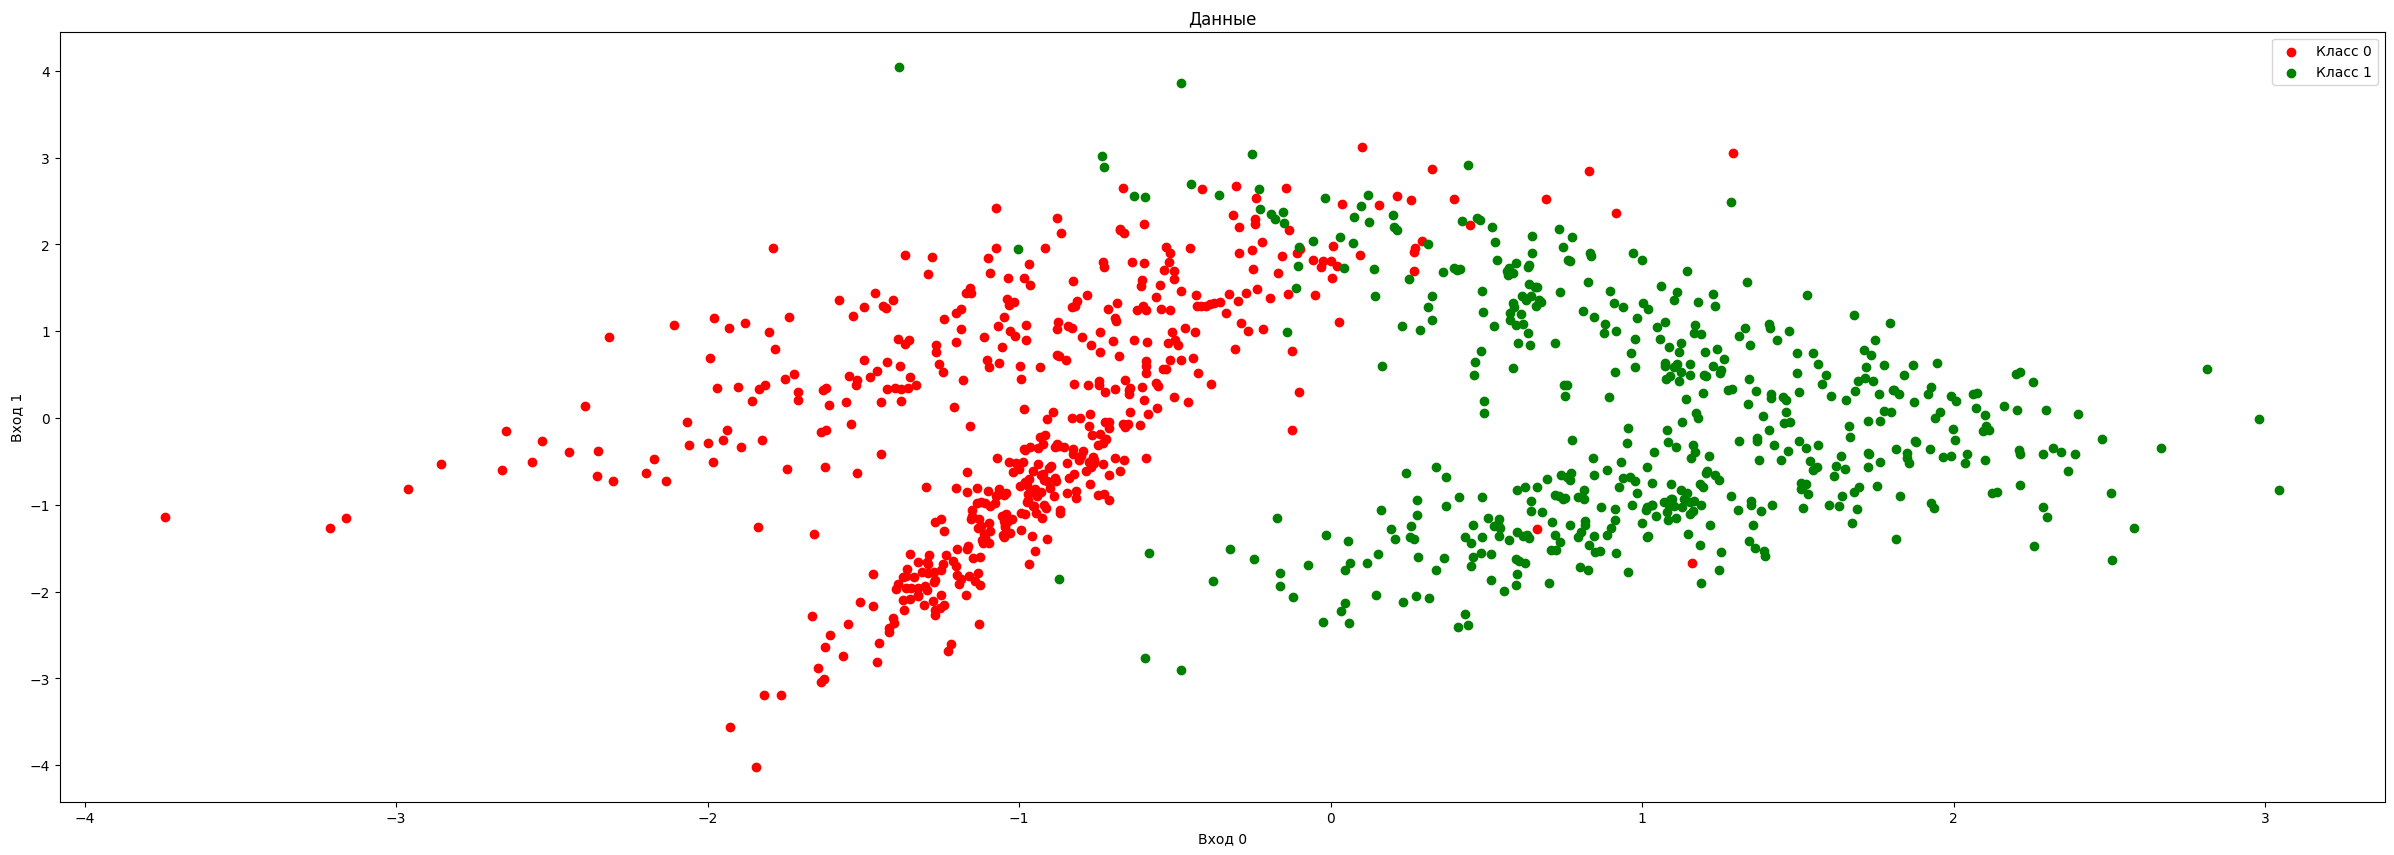

In [ ]:
# Визуализируем данные.
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

fig, ax = plt.subplots(figsize=(30, 10))
colors = ["red", "green"]
for target in range(2):
    plt.scatter(X[y == target, 0], X[y == target, 1], label=f"Класс {target}", c=colors[target])

plt.title("Данные")
plt.xlabel("Вход 0")
plt.ylabel("Вход 1")
plt.legend()
plt.show()

In [ ]:
# Делаем сетку точек на плоскости, чтобы потом проверять предсказания нашей модели.
xy_min, xy_max = -4, 4
grid_size = 120
grid = torch.linspace(xy_min, xy_max, grid_size, dtype=torch.float32)
grid_x_1, grid_x_2 = torch.meshgrid(grid, grid, indexing='ij')

grid = torch.stack([grid_x_1.reshape(-1), grid_x_2.reshape(-1)], dim=1)
print(grid.shape, grid.dtype)

torch.Size([14400, 2]) torch.float32


In [ ]:
# Обучим простую двухслойную нейросеть на задачу классификации.
model = torch.nn.Sequential(
    OrderedDict([
        ("linear_1", torch.nn.Linear(2, 4)),
        ("activation_1", torch.nn.ReLU()),
        ("linear_2", torch.nn.Linear(4, 2)),
        ("log_softmax", torch.nn.LogSoftmax(dim=1)),
    ])
)

model

Sequential(
  (linear_1): Linear(in_features=2, out_features=4, bias=True)
  (activation_1): ReLU()
  (linear_2): Linear(in_features=4, out_features=2, bias=True)
  (log_softmax): LogSoftmax(dim=1)
)

In [ ]:
# Оптимайзеры.
optimizer = torch.optim.SGD(
    model.parameters(),  # Передаём все тензоры, участвующие в градиентном спуске.
    lr=1.,               # learning rate — величина шага градиентного спуска.
)

# Две основные функции для оптимайзера:
#  1. optimizer.step. Сделать шаг оптимизации, т. е. в случае простого SGD
#     применить w -= lr * w.grad для всех тензоров, участвующих в обучении.
#  2. optimizer.zero_grad. Обнулить все градиенты, т. е. применить w.grad.zero_()
#     для всех тензоров, участвующих в обучении.

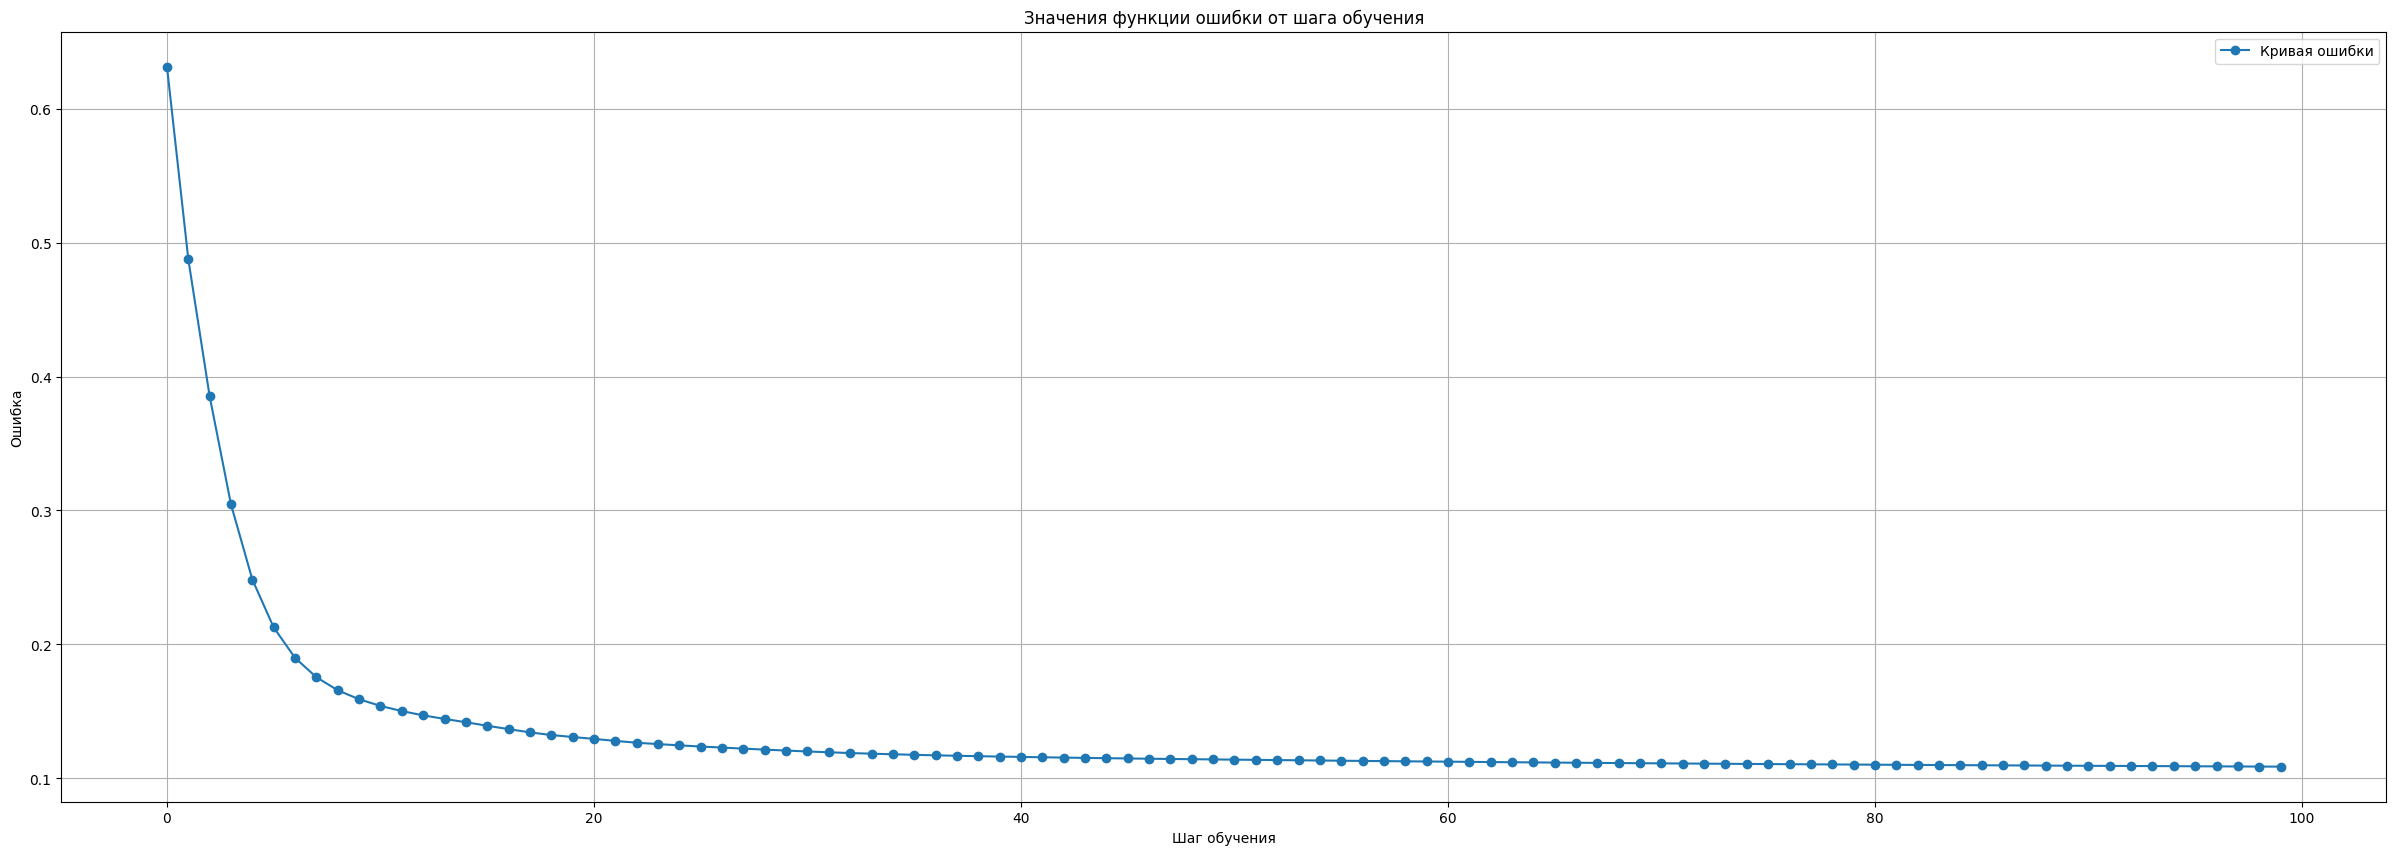

In [ ]:
losses = []      # Для визуализации будем собирать информацию об ошибке по ходу обучения.
grid_preds = []  # Также будем собирать информацию о предсказаниях модели.

# Используем NLLLoss, т. к. задача классификации
#  и мы предсказываем лог-вероятности классов.
loss_fn = torch.nn.NLLLoss()

for step in range(1, 101):
    optimizer.zero_grad()      # Обнуляем градиенты.
    y_pred = model(X)          # Считаем прямой проход на всех данных.
    loss = loss_fn(y_pred, y)  # Считаем величину ошибки.

    # Записываем значение ошибки в список, чтобы позже визуализировать
    #  (.item() возвращает само значение внутри тензора из одного значения).
    losses.append(loss.item())

    loss.backward()   # Считаем градиенты для всех задействованных тензоров.
    optimizer.step()  # Делаем шаг градиентного спуска.

    with torch.no_grad():  # Используем обёртку, т. к. нам не требуются градиенты на наших тестовых предсказаниях.
        grid_preds.append(model(grid))


# Визуализируем, как менялось значение ошибки на данных.
fig, ax = plt.subplots(figsize=(30, 10))
plt.plot(losses, "o-", label="Кривая ошибки")

plt.title("Значения функции ошибки от шага обучения")
plt.xlabel("Шаг обучения")
plt.ylabel("Ошибка")
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Посмотрим, как выглядят предсказания нашей модели на последнем шаге.
pred_class_probs = grid_preds[-1].exp()  # Получаем вероятности классов на последнем шаге обучения для каждой точки сетки.
print(f"Предсказанные вероятности классов:\n{pred_class_probs}\n")

pred_class = 1 * (pred_class_probs[:, 1] > 0.5)  # Предсказанные классы умножаем на 1, чтобы получить int вместо bool.
print(f"Предсказанные классы:\n{pred_class}")

Предсказанные вероятности классов:
tensor([[1.0000e+00, 2.0499e-08],
        [1.0000e+00, 2.1830e-08],
        [1.0000e+00, 2.3248e-08],
        ...,
        [1.5797e-06, 1.0000e+00],
        [1.7832e-06, 1.0000e+00],
        [2.0130e-06, 1.0000e+00]])

Предсказанные классы:
tensor([0, 0, 0,  ..., 1, 1, 1])


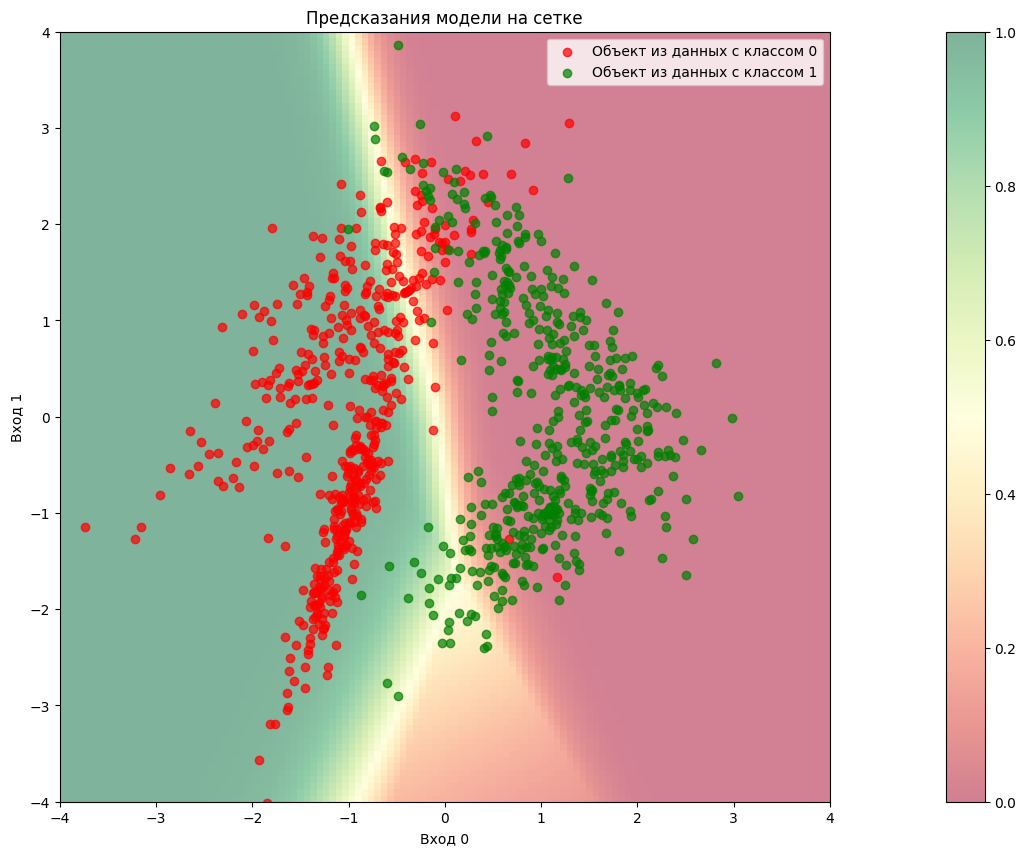

In [ ]:
# Отрисовываем.
fig, ax = plt.subplots(figsize=(30, 10))
colors = ["red", "green"]
for target in range(2):
    plt.scatter(
        X[y == target, 0],
        X[y == target, 1],
        marker="o",
        label=f"Объект из данных с классом {target}",
        c=colors[target],
        alpha=0.7,
    )

plt.imshow(
    pred_class_probs[:, 0].reshape(grid_size, grid_size).T,
    vmin=0.,
    vmax=1.,
    cmap=mpl.colormaps["RdYlGn"],
    extent=(xy_min, xy_max, xy_min, xy_max),
    alpha=0.5,
)

plt.title("Предсказания модели на сетке")
plt.xlabel("Вход 0")
plt.ylabel("Вход 1")
plt.legend()
plt.colorbar()
plt.show()

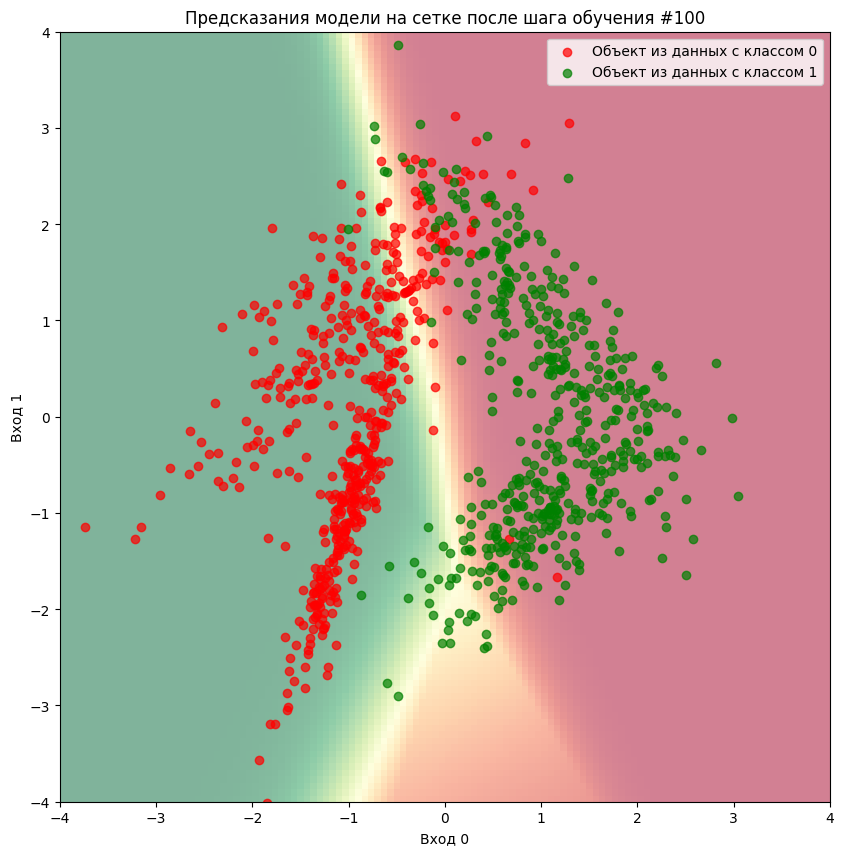

In [ ]:
# Анимация того, как обучалась модель.
from time import sleep
from IPython.display import clear_output

draw_x0s = []
draw_x1s = []
draw_y0s = []
draw_y1s = []
all_pred_class_probs = []

# Предпосчитываем анимации для скорости.
for i in range(100):
    pred_class_probs = grid_preds[i].exp()

    draw_x0s.append(X[y == 0, 0])
    draw_x1s.append(X[y == 1, 0])

    draw_y0s.append(X[y == 0, 1])
    draw_y1s.append(X[y == 1, 1])

    all_pred_class_probs.append(pred_class_probs[:, 0].reshape(grid_size, grid_size).T)

# Отрисовываем.
for i in range(100):
    clear_output(True)

    fig, ax = plt.subplots(figsize=(30, 10))
    for xs, ys, meta in [
        (draw_x0s, draw_y0s, ("o", f"Объект из данных с классом 0", "red")),
        (draw_x1s, draw_y1s, ("o", f"Объект из данных с классом 1", "green")),
    ]:
        plt.scatter(
            xs[i],
            ys[i],
            marker=meta[0],
            label=meta[1],
            c=meta[2],
            alpha=0.7,
        )

    plt.imshow(
    all_pred_class_probs[i],
        vmin=0.,
        vmax=1.,
        cmap=mpl.colormaps["RdYlGn"],
        extent=(xy_min, xy_max, xy_min, xy_max),
        alpha=0.5,
    )

    plt.title(f"Предсказания модели на сетке после шага обучения #{i+1}")
    plt.xlabel("Вход 0")
    plt.ylabel("Вход 1")
    plt.legend()
    plt.show()

#     sleep(0.2)